In [8]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [9]:
api = wandb.Api()

In [10]:
runs = api.runs(path="harvardml/opt-olmo")

In [11]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',   'NovoGrad', 'Adafactor', 'Lion', 'Signum', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [12]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 25000
groups =  ["wd-all-4", "wd-all-5"] # ["wd-all-1", "wd-all-2"]

for run in runs:
    if run.group in groups:
        history = run.history(samples=25000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict["learning_rate"] = run.config["optimizer"]["learning_rate"]
        run_dict["weight_decay"] = run.config["optimizer"]["weight_decay"]
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [13]:
df.head()

,id,group,optimizer,learning_rate,weight_decay,val_loss,step
0,kijthn6a,wd-all-5,novagradw_ours,0.00316,10.0,7.162034,25000.0
0,rece9prn,wd-all-5,novagradw_ours,0.00316,1.0,4.109503,25000.0
0,dldem3qi,wd-all-5,adafactorw,0.00316,100.0,10.227961,25000.0
0,dmo5hk9f,wd-all-5,novagradw_ours,0.00316,100.0,7.639336,25000.0
0,86zmbtyh,wd-all-5,adafactorw,0.00316,10.0,6.030707,25000.0


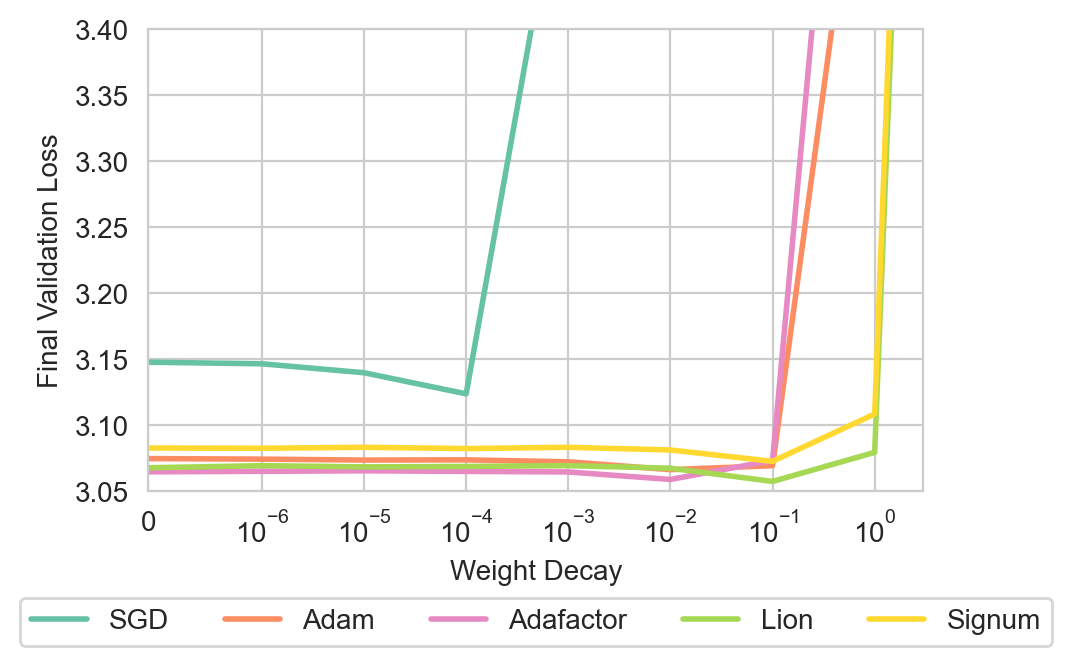

In [16]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

for optimizer in optimizers:
    if optimizer in ["sophiag", "novagradw_ours"]:
        continue
    if optimizer in df["optimizer"].unique():
        optimizer_df = df[df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by="weight_decay")
        optimizer_df = optimizer_df.groupby("weight_decay").min().reset_index()
        plt.plot(optimizer_df["weight_decay"], optimizer_df["val_loss"], 
                label=name_map[optimizer],
                linewidth=2,
                color=color_map[optimizer],
                # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
        )

plt.xscale("symlog", linthresh=1e-6)
plt.ylim(3.05, 3.4)
plt.xlim(0, 3)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel("Weight Decay")
plt.ylabel("Final Validation Loss")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))


plt.savefig('../figures/wd.png', bbox_inches='tight')
plt.show()